# Pipeline Of The Notebook

**1.EDA. We found that our datasets(both two datasets) are well-structured.However,the distribution of the target variable 'PitNextLap' is highly imbalanced,which means we should use class weights,resampling and other methods in the modeling process.**

**2.Feature Engineering. Through the heatmap, We found that "RaceProgress"and"LapNumber" are highly collinear. I choose to delete "Lapnumber" since it's more difficult to be combined with other features than "Raceprogress".Another reanson is that "Raceprogress" is a normalized feature.**

**3.Using Optuna to find hyperparameters**

**4.Stratified 5-fold stacking ensemble pipeline using LightGBM, XGBoost, and CatBoost as base models and Logistic Regression as a meta-learner**

# Scheme Introduction: Modeling Approach without LabelEncoder

**This is a lightweight multi-model stacking framework designed for F1 pit stop prediction. By splitting features and assigning different processing tasks to individual models, the solution greatly cuts down training time while maintaining acceptable prediction accuracy.**

Feature and Model Division
LightGBM and XGBoost only take pure numerical features after data cleaning and feature derivation. Categorical features are excluded to reduce feature dimensions and computational cost, achieving fast training speed.
CatBoost adopts the full feature set, including both numerical features and original categorical features such as driver, tire compound and race track. It leverages native categorical processing capability, requiring no manual encoding and effectively capturing correlations between categorical and numerical information.
5-Fold Cross Validation Stacking
Stratified 5-fold cross validation is applied to keep consistent data distribution in each fold and mitigate overfitting. Out-of-fold predictions and test set predictions are generated from three base models respectively. Logistic regression serves as the meta learner to integrate results from base models and produce final prediction outputs.

Advantages
Remarkably improved training efficiency. Removing categorical inputs reduces calculation burden of LightGBM and XGBoost, making the overall 5-fold training much faster compared with the scheme using LabelEncoder.
Simplified coding workflow. Manual categorical encoding procedures are eliminated, lowering potential bugs in data preprocessing.
Competitive overall performance. The average 5-fold OOF AUC stays at a high level, with only a slight accuracy drop against the unified LabelEncoder encoding solution.

Limitations & Applicable Scenarios
Applicable scenarios: Suitable for rapid model iteration, idea verification and running under limited hardware resources.
Limitations: Information obtained by different base models is not identical. The lack of categorical data input in LightGBM and XGBoost causes incomplete feature perception, resulting in slightly weaker generalization ability and lower final score than the fully encoded scheme.

# 1.EDA

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white",palette="Set2")
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_train=pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
df_test=pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/test.csv")
df_original=pd.read_csv("/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv")

In [3]:
df_train.head()


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
def show_info(df):
    info_df=pd.DataFrame(index=list(df))
    info_df["Dtype"]=df.dtypes
    info_df["Count"]=df.count()
    info_df["#Unique"]=df.nunique()
    info_df["#Missing"]=df.isnull().sum()
    info_df["%Missing"]=(df.isnull().sum()/len(df)*100).round(2)
    return info_df

In [5]:
show_info(df_train)

,Dtype,Count,#Unique,#Missing,%Missing
id,int64,439140,439140,0,0.0
Driver,object,439140,887,0,0.0
Compound,object,439140,5,0,0.0
Race,object,439140,26,0,0.0
Year,int64,439140,4,0,0.0
PitStop,int64,439140,2,0,0.0
LapNumber,int64,439140,78,0,0.0
Stint,int64,439140,8,0,0.0
TyreLife,float64,439140,78,0,0.0
Position,int64,439140,20,0,0.0


In [6]:
show_info(df_test)

,Dtype,Count,#Unique,#Missing,%Missing
id,int64,188165,188165,0,0.0
Driver,object,188165,801,0,0.0
Compound,object,188165,5,0,0.0
Race,object,188165,26,0,0.0
Year,int64,188165,4,0,0.0
PitStop,int64,188165,2,0,0.0
LapNumber,int64,188165,77,0,0.0
Stint,int64,188165,8,0,0.0
TyreLife,float64,188165,77,0,0.0
Position,int64,188165,20,0,0.0


In [7]:
show_info(df_original)

,Dtype,Count,#Unique,#Missing,%Missing
Driver,object,101371,31,0,0.00
LapNumber,int64,101371,78,0,0.00
Compound,object,101305,5,66,0.07
Stint,int64,101371,8,0,0.00
TyreLife,float64,101371,78,0,0.00
Position,int64,101371,20,0,0.00
LapTime (s),float64,101371,40779,0,0.00
Race,object,101371,28,0,0.00
Year,int64,101371,4,0,0.00
LapTime_Delta,float64,101371,54084,0,0.00


In [8]:
df_train=pd.concat([df_train,df_original],ignore_index=True)

In [9]:

pit_counts = df_train['PitNextLap'].value_counts()
print("number：\n", pit_counts)


pit_ratio = df_train['PitNextLap'].value_counts(normalize=True) * 100
print("ratio：\n", pit_ratio.round(2))

number：
 PitNextLap
0.0    427301
1.0    113210
Name: count, dtype: int64
ratio：
 PitNextLap
0.0    79.06
1.0    20.94
Name: proportion, dtype: float64


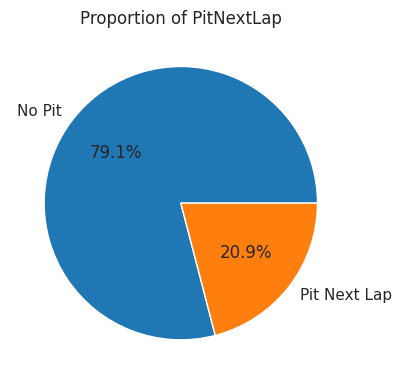

In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 2)
df_train['PitNextLap'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['No Pit', 'Pit Next Lap'],
    colors=['#1f77b4', '#ff7f0e']
)
plt.title('Proportion of PitNextLap')
plt.ylabel('')

plt.tight_layout()
plt.show()

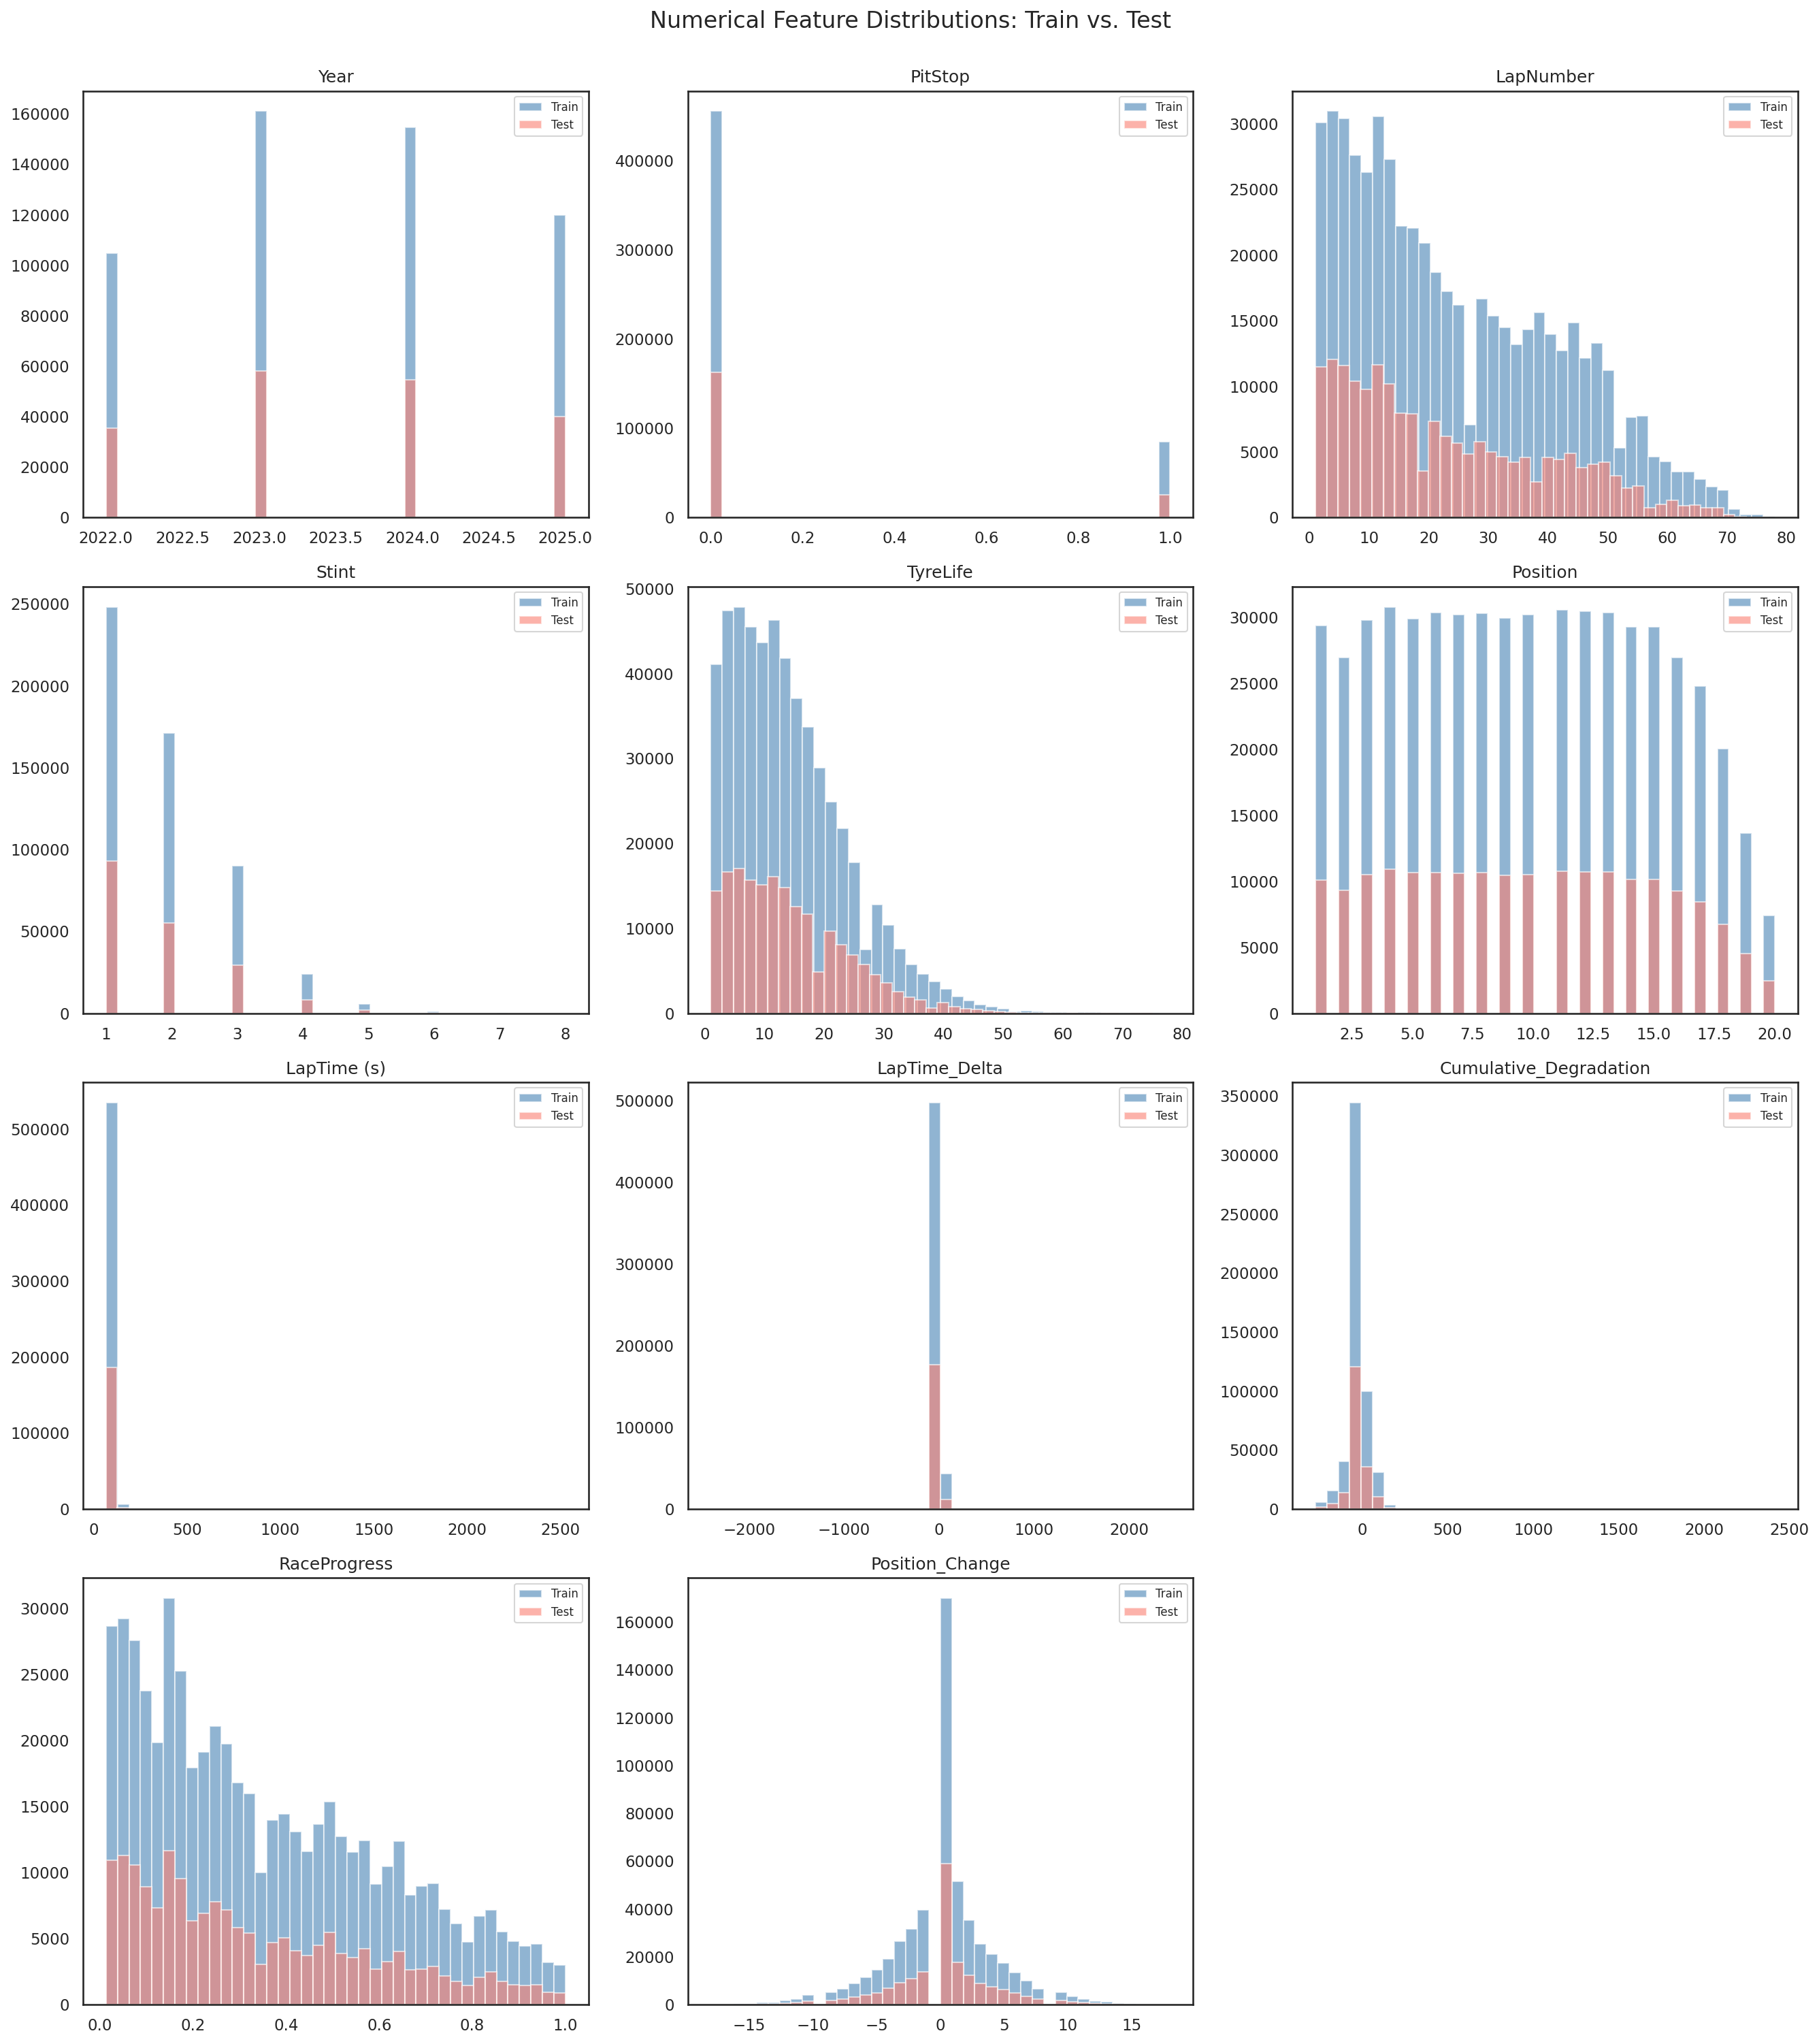

In [11]:
# Visualizing distributions of numerical features 
num_cols = [
    "Year","PitStop","LapNumber","Stint","TyreLife",
    "Position","LapTime (s)","LapTime_Delta","Cumulative_Degradation","RaceProgress","Position_Change"
]

fig, axes = plt.subplots(4, 3, figsize=(18, 20), dpi=150)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_train[col], bins=40, alpha=0.6, label='Train', color='steelblue')
    axes[i].hist(df_test[col], bins=40, alpha=0.6, label='Test', color='salmon')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)


axes[-1].set_visible(False)

fig.suptitle('Numerical Feature Distributions: Train vs. Test', fontsize=16, y=1)
plt.tight_layout()
plt.show()

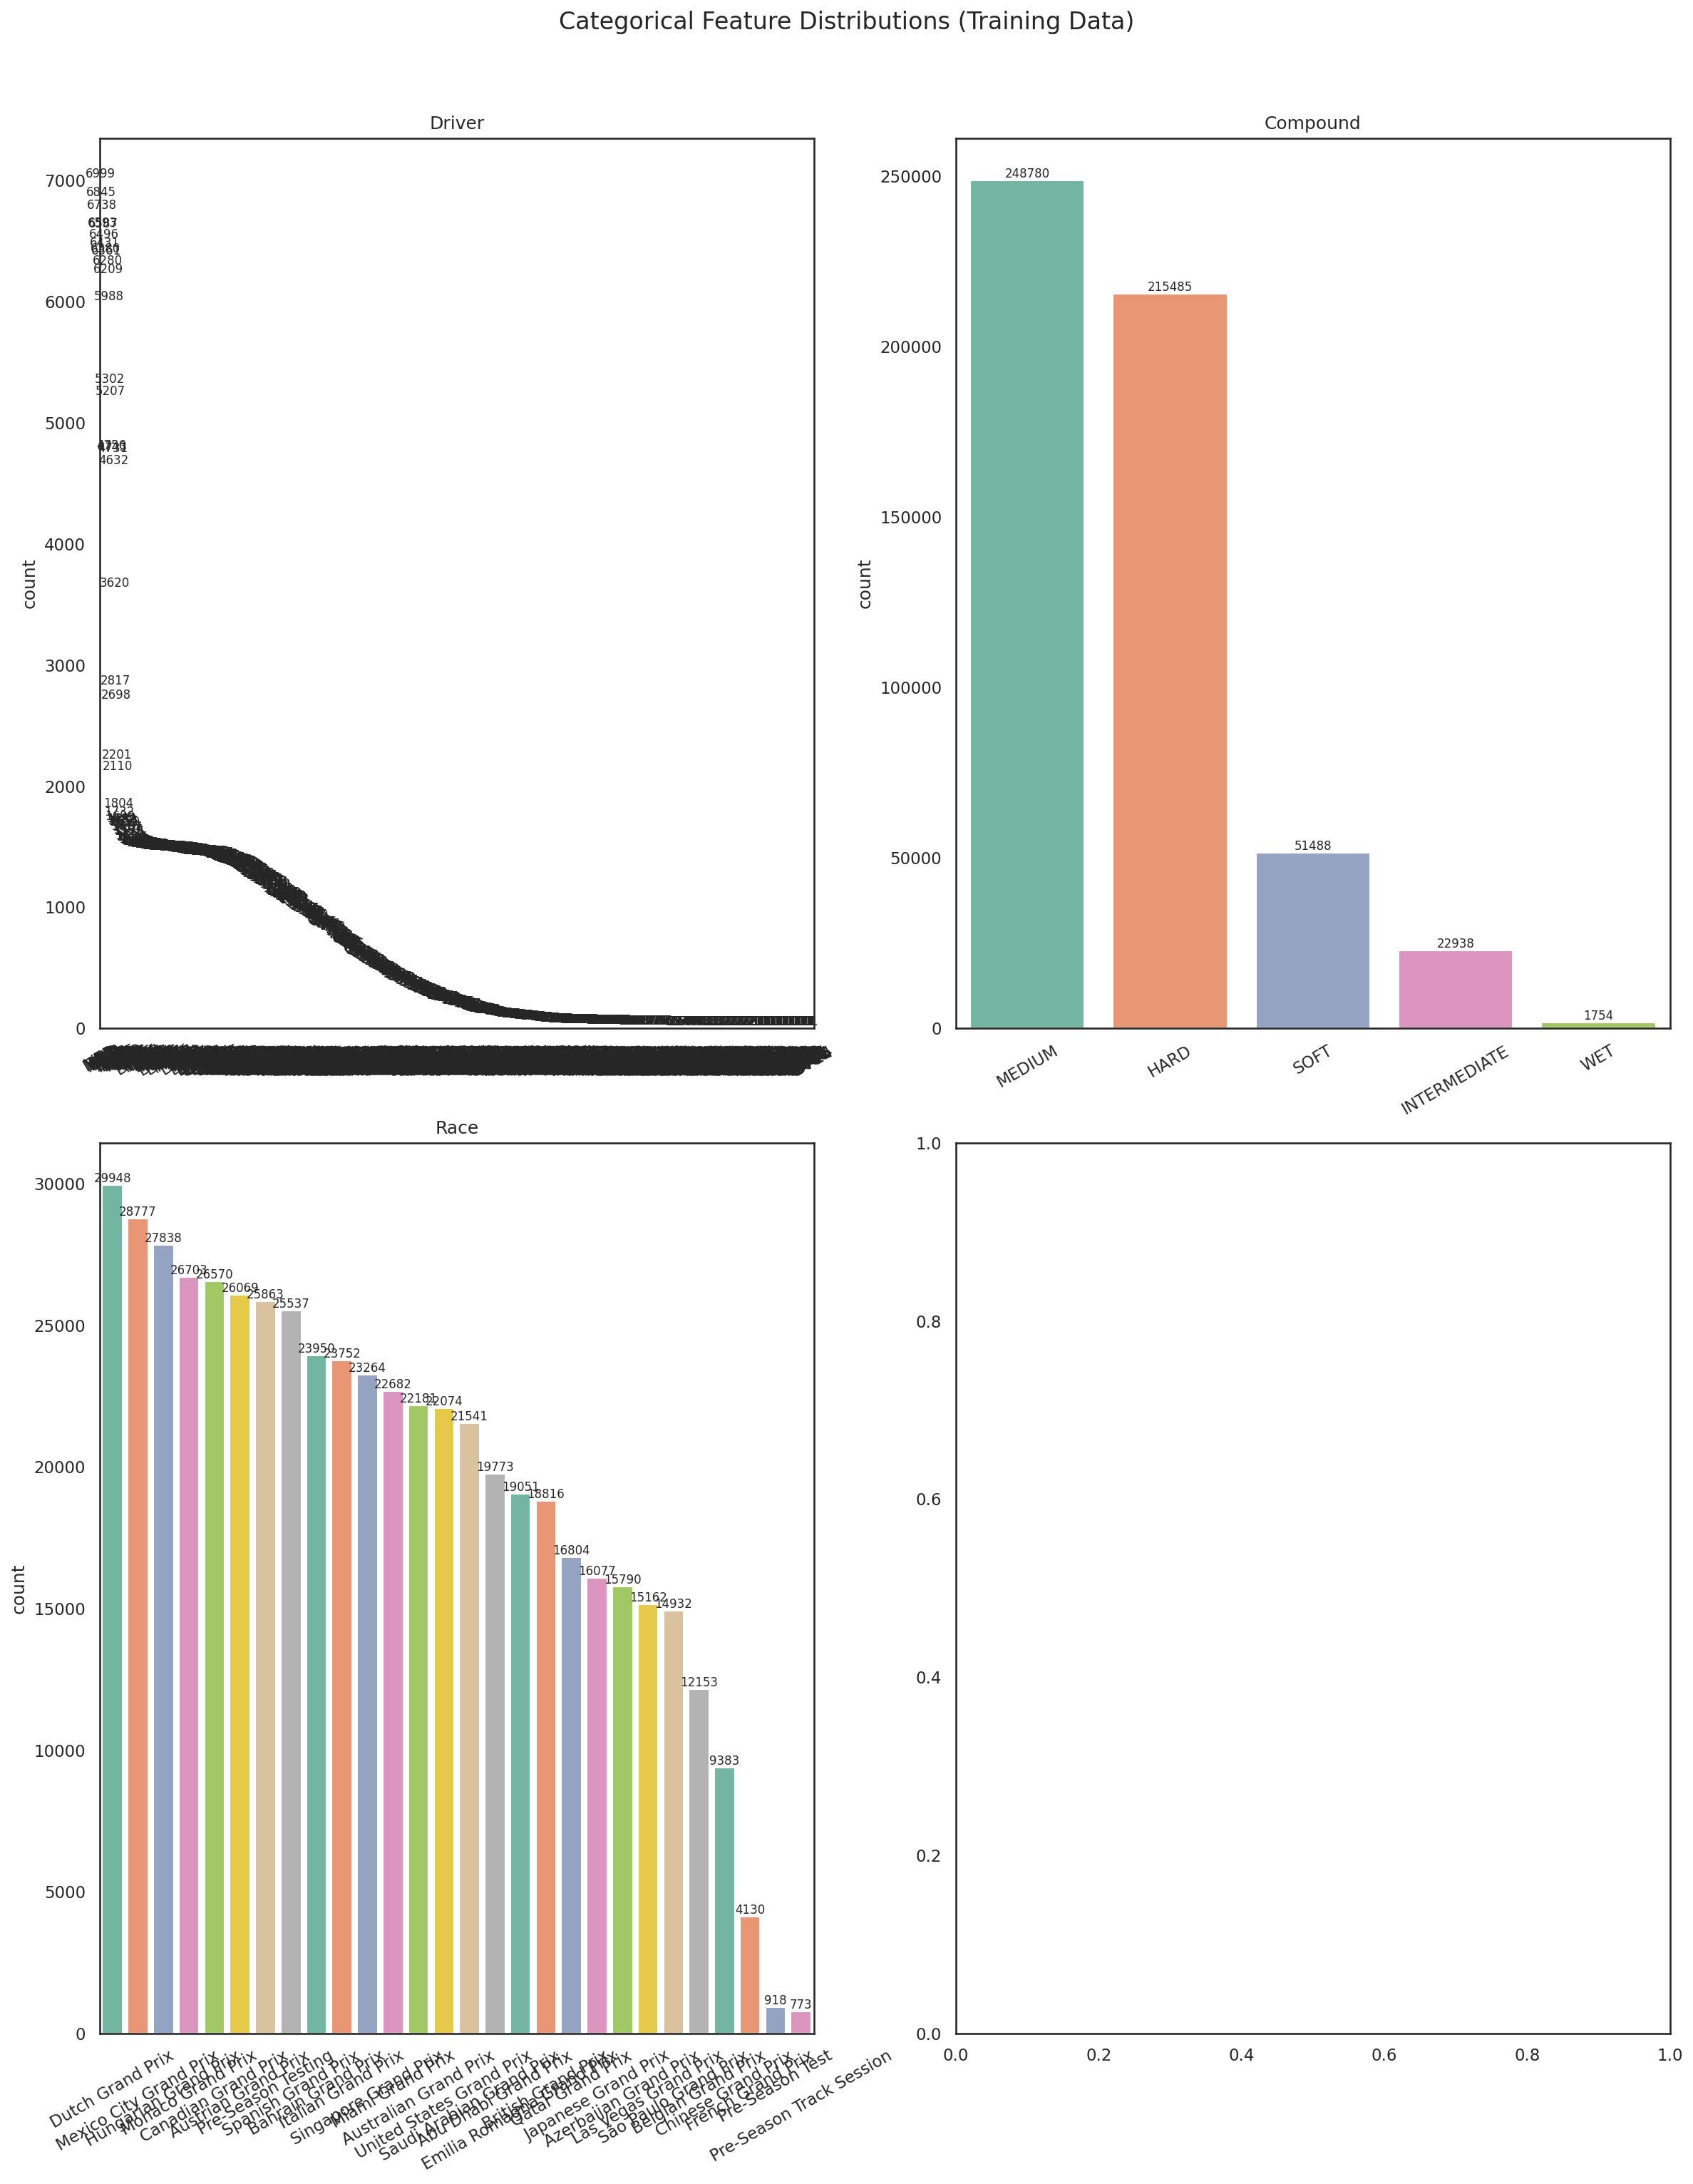

In [12]:
# Visualizing distributions of categorical features
cat_cols = ["Driver","Compound","Race"]
fig, axes = plt.subplots(2, 2, figsize=(16, 20), dpi=150)
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order_vals = df_train[col].value_counts().index
    ax = axes[i]
    sns.countplot(x=col, data=df_train, order=order_vals, ax=ax, palette='Set2')

    for label in ax.containers:
        ax.bar_label(label, fontsize=8)
    
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Categorical Feature Distributions (Training Data)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



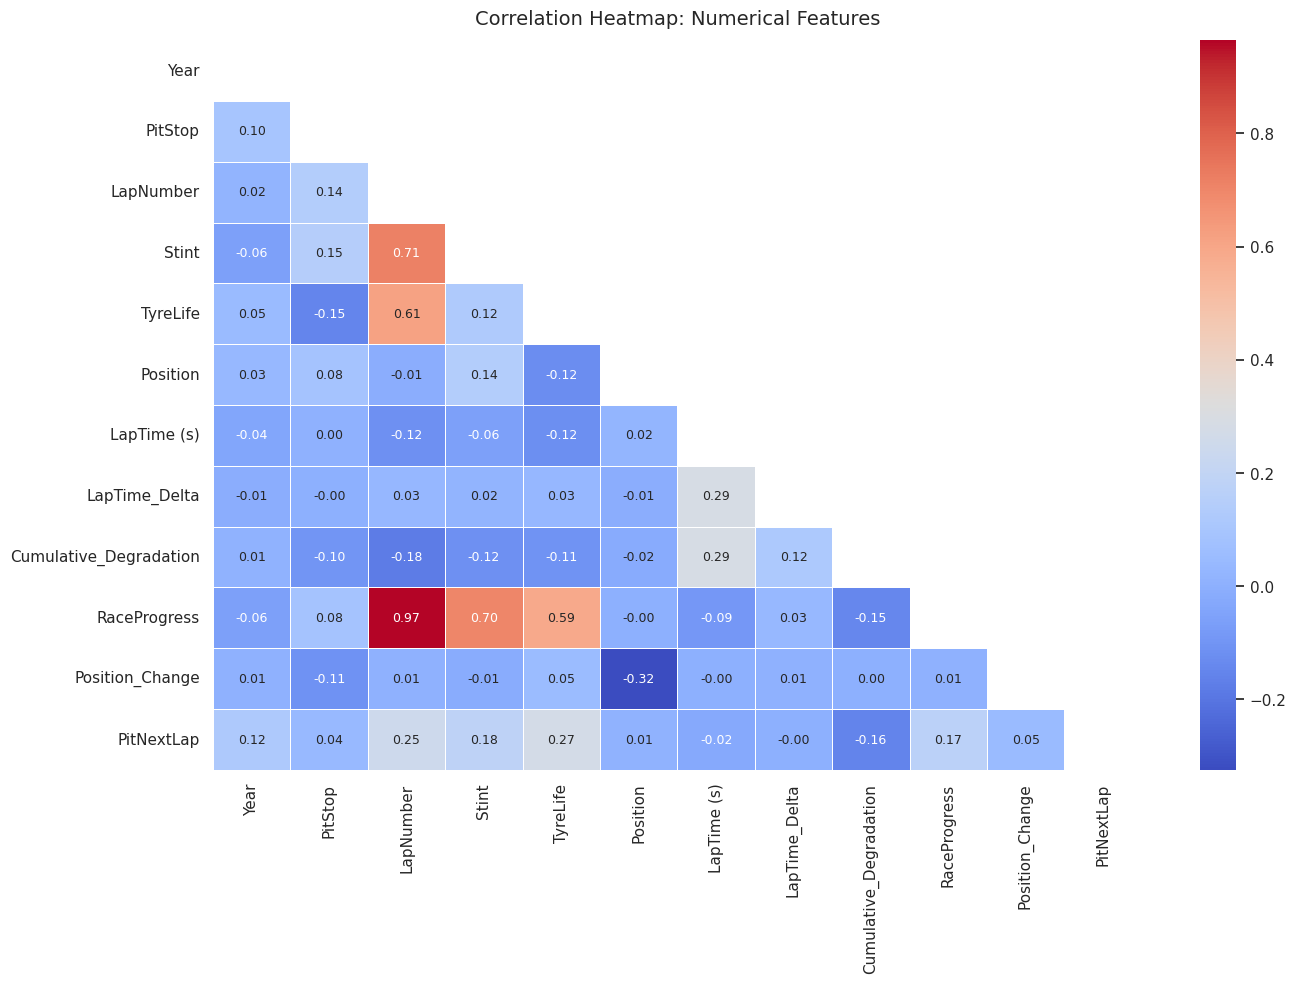

In [13]:
#Heatmap
num_cols_target = [
    'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife',
    'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
    'RaceProgress', 'Position_Change','PitNextLap'
]


plt.figure(figsize=(14, 10))


corr = df_train[num_cols_target].corr()


sns.heatmap(
    corr,
    annot=True,        
    cmap='coolwarm',  
    mask=np.triu(corr),
    linewidths=0.5,
    fmt='.2f',       
    annot_kws={'size': 9}
)

plt.title('Correlation Heatmap: Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 2.Feature Engineering

In [14]:
def engineer_features(df):
    df = df.copy()
    
    # 1. Tire life transformation features
    df['TyreLife_Squared'] = df['TyreLife'] ** 2  # Quadratic term to capture non-linear wear
    df['TyreLife_Log'] = np.log1p(df['TyreLife'])  # Log transform to reduce skewness
    df['TyreLife_Bin'] = pd.cut(df['TyreLife'], bins=[0, 10, 20, 30, 50], 
                               labels=[0, 1, 2, 3]).astype(float)  # Binned tire life categories
    
    # 2. Interaction features: Stint & Race Progress with tire life
    df['Stint_TyreLife_Interaction'] = df['Stint'] * df['TyreLife']  # Tire usage * stint count
    df['RaceProgress_TyreLife'] = df['RaceProgress'] * df['TyreLife']  # Race progress * tire life (higher = more likely to pit)
    
    
    # 3. Degradation & lap time interaction features
    df['Degradation_Per_Lap'] = df['Cumulative_Degradation'] / (df['LapNumber'] + 1)  # Average degradation per lap
    df['LapTime_Degradation'] = df['LapTime (s)'] * np.abs(df['Cumulative_Degradation'])  # Lap time * degradation interaction
    
    # 4. Position & racing context features
    df['Position_Racing'] = np.abs(df['Position_Change'])  # Absolute position change
    df['Position_TyreLife'] = df['Position'] * df['TyreLife']  # Lower position + old tires = higher pit probability

    
    # 5. Speed consistency features
    df['LapTime_Ratio'] = df['LapTime (s)'] / (df['LapTime (s)'].max() + 1e-8) # Normalized lap time
    df['LapTime_Delta_Abs'] = np.abs(df['LapTime_Delta'])  # Absolute lap time delta
    df['LapTime_Consistency'] = 1.0 / (1.0 + np.abs(df['LapTime_Delta']))  # Speed consistency (higher = more stable)

    # 6. Race phase features
    df['Early_Race'] = (df['RaceProgress'] < 0.3).astype(float)
    df['Mid_Race'] = ((df['RaceProgress'] >= 0.3) & (df['RaceProgress'] < 0.7)).astype(float)
    df['Late_Race'] = (df['RaceProgress'] >= 0.7).astype(float)
    
    # 7. Compound degradation mapping
    compound_degradation = {'SOFT': 3, 'MEDIUM': 2, 'HARD': 1, 'INTERMEDIATE': 4, 'WET': 5}
    df['Compound_DegradationRate'] = df['Compound'].map(compound_degradation).astype(float)
    
    # 8. Pit stop urgency features (core business signals)
    df['Pit_Urgency'] = (df['TyreLife'] / 50) * df['Compound_DegradationRate'] * (1 + df['Late_Race']) * (1 - df['RaceProgress'])
    df['Stint_Age'] = df['Stint'] * df['TyreLife'] / 30  # Combined stint count and tire wear
    df['LapTime_Delta_TyreLife'] = df['LapTime_Delta'] * df['TyreLife']  # Lap time delta * tire life

    cat_cols = ['Driver', 'Compound', 'Race']
    cat_cols = ['Driver', 'Compound', 'Race']
    #for col in cat_cols:
         # Fill possible missing values and convert to string
        #df[col] = df[col].fillna("unknown").astype(str)
        # Drop unnecessary columns
    drop_cols = ['id','LapNumber']
    df = df.drop(columns=drop_cols, errors='ignore')
    
    return df


# 3.Optuna to find the best hyperparamaters

In [15]:
def prepare_data(df_train, df_test, cat_cols, target_col):
    # 1. Feature Engineering
    X_full = engineer_features(df_train).reset_index(drop=True)
    X_test_full = engineer_features(df_test).reset_index(drop=True)

    # 2. Separate Target Variable
    y = X_full[target_col].reset_index(drop=True)
    X_full = X_full.drop(columns=[target_col])

    # 3. Align Test Set Columns with Train Set
    X_test_full = X_test_full.reindex(columns=X_full.columns, fill_value=0)

    # 4. Split Numerical and Categorical Features
    num_cols = [col for col in X_full.columns if col not in cat_cols]
    X_train_num = X_full[num_cols].copy().reset_index(drop=True)
    X_test_num = X_test_full[num_cols].copy().reset_index(drop=True)

    # 5. Filter Samples with Missing Values (Synchronized across all datasets)
    mask = ~X_train_num.isna().any(axis=1)
    print(f"Rows before filtering: {len(X_train_num)}, Rows after filtering: {mask.sum()}")
    
    X_train_num = X_train_num.loc[mask].reset_index(drop=True)
    X_full = X_full.loc[mask].reset_index(drop=True)
    y = y.loc[mask].reset_index(drop=True)

    # 6. Assertion Checks to Ensure Data Consistency
    assert len(X_train_num) == len(y), "X_train_num and y length mismatch!"
    assert set(X_test_full.columns) == set(X_full.columns), "Test set columns do not match train set!"

    print(f"✅ Training set rows: {len(X_train_num)},Test set columns: {len(X_test_full.columns)}")
    return X_train_num, X_test_num, X_full, X_test_full, y
    
cat_cols = ['Driver', 'Compound', 'Race']
X_train_num, X_test_num, X_full, X_test_full, y = prepare_data(df_train, df_test, cat_cols, 'PitNextLap')

Rows before filtering: 540511, Rows after filtering: 100795
✅ Training set rows: 100795,Test set columns: 33


In [16]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

lgb_fixed = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1
}

def objective(trial):
    params = {
        **lgb_fixed,
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True)
    }
    
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train_num, y_train,
        eval_set=[(X_val_num, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    
    y_pred_proba = model.predict_proba(X_val_num)[:,1]
    return roc_auc_score(y_val, y_pred_proba)

RUN_OPTUNA = False
if RUN_OPTUNA:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    print(f"\nRoc Auc: {study.best_value:.4f}")
    print(f"Best Parameters: {study.best_params}")
    lgb_params = {**lgb_fixed, **study.best_params}
else:
    lgb_params = {
        **lgb_fixed,
        'n_estimators': 883,
        'learning_rate': 0.121,
        'num_leaves': 272,
        'max_depth': 11,
        'min_child_samples': 41,
        'subsample': 0.9444,
        'colsample_bytree': 0.8,
        'reg_alpha': 1.478,
        'reg_lambda': 0.126
    }
    print("Using pre-recorded best parameters.")

Using pre-recorded best parameters.


In [17]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score



xgb_fixed = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'scale_pos_weight': 1,  
    'random_state': 42,
    'verbosity': 0
}

def objective(trial):
    params = {
        **xgb_fixed,
        'n_estimators': trial.suggest_int('n_estimators', 200, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 10.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True)
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train_num, y_train,
        eval_set=[(X_val_num, y_val)],
        verbose=False
        
    )

    y_pred_proba = model.predict_proba(X_val_num)[:, 1]
    return roc_auc_score(y_val, y_pred_proba)

RUN_OPTUNA = False
if RUN_OPTUNA:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=True)

    print(f"\nBest AUC: {study.best_value:.4f}")
    print(f"Best Parameters: {study.best_params}")

    xgb_params = {**xgb_fixed, **study.best_params}
else:
    xgb_params = {
        **xgb_fixed,
        'n_estimators': 250,
        'learning_rate': 0.0967,
        'max_depth': 10,
        'min_child_weight': 5,
        'subsample': 0.633,
        'colsample_bytree': 0.530,
        'gamma': 0.816,
        'reg_alpha': 1.3,
        'reg_lambda': 0.001
    }
    print("Using pre-recorded best parameters.")

Using pre-recorded best parameters.


In [18]:
import optuna
import catboost as cb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

cb_fixed = {
    'objective': 'Logloss',
    'eval_metric': 'AUC',
    'auto_class_weights': 'Balanced',
    'random_state': 42,
    'verbose': 0,
    'use_best_model': True 
}

def objective(trial):
    params = {
        **cb_fixed,
        'iterations': trial.suggest_int('iterations', 200, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 12),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-4, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 10.0),
        'border_count': trial.suggest_int('border_count', 32, 255)
    }

    model = cb.CatBoostClassifier(**params)
    model.fit(
        X_train_full, y_train,
        eval_set=[(X_val_full, y_val)],
        verbose=False,cat_features=cat_features_idx
    )

    y_pred_proba = model.predict_proba(X_val_full)[:, 1]
    return roc_auc_score(y_val, y_pred_proba)

RUN_OPTUNA = False
if RUN_OPTUNA:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    print(f"\nBest AUC: {study.best_value:.4f}")
    print(f"Best Parameters: {study.best_params}")

    cb_params = {**cb_fixed, **study.best_params}
else:
    cb_params = {
        **cb_fixed,
        'cat_features':['Driver','Compound','Race'],
        'iterations': 515,
        'learning_rate': 0.091,
        'depth': 11,
        'l2_leaf_reg': 0.774,
        'subsample': 0.771,
        'colsample_bylevel': 0.947,
        'bagging_temperature': 6.77,
        'border_count': 240
    }
    print("Using pre-recorded best parameters.")


Using pre-recorded best parameters.


# 4.Stratified 5-fold stacking ensemble pipeline using LightGBM, XGBoost, and CatBoost as base models and Logistic Regression as a meta-learner

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# 5 fold stacking
N_FOLDS = 5
kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# OOF arrays
oof_lgb = np.zeros(len(X_train_num))
oof_xgb = np.zeros(len(X_train_num))
oof_cb = np.zeros(len(X_train_num))

#test prediction arrays
test_lgb = np.zeros(len(X_test_num))
test_xgb = np.zeros(len(X_test_num))
test_cb = np.zeros(len(X_test_full))

# auc score
lgb_scores = []
xgb_scores = []
cb_scores = []


for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_num, y)):
    print(f"---- Fold {fold + 1} / {N_FOLDS} ----")

    # LGB/XGB !!Only deal with numerical features
    Xtr_num = X_train_num.iloc[train_idx]
    Xval_num = X_train_num.iloc[val_idx]
    # CatBoost !!deal with all the features
    Xtr_full = X_full.iloc[train_idx]
    Xval_full = X_full.iloc[val_idx]
    ytr = y.iloc[train_idx]
    yval = y.iloc[val_idx]

    # --- LightGBM dealing with numerical features ---
    lgb_model = lgb.LGBMClassifier(**lgb_params)
    lgb_model.fit(
        Xtr_num, ytr,
        eval_set=[(Xval_num, yval)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )
    oof_lgb[val_idx] = lgb_model.predict_proba(Xval_num)[:, 1]
    test_lgb += lgb_model.predict_proba(X_test_num)[:, 1] / N_FOLDS

    lgb_auc = roc_auc_score(yval, oof_lgb[val_idx])
    lgb_scores.append(lgb_auc)
    print(f"LGB Fold AUC: {lgb_auc:.4f}")

    # --- XGBoost dealing with numerical features ---
    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(
        Xtr_num, ytr,
        eval_set=[(Xval_num, yval)],
        verbose=False
    )
    oof_xgb[val_idx] = xgb_model.predict_proba(Xval_num)[:, 1]
    test_xgb += xgb_model.predict_proba(X_test_num)[:, 1] / N_FOLDS

    xgb_auc = roc_auc_score(yval, oof_xgb[val_idx])
    xgb_scores.append(xgb_auc)
    print(f"XGB Fold AUC: {xgb_auc:.4f}")

    # --- CatBoost dealing with all the features ---
    cb_model = CatBoostClassifier(**cb_params)
    cb_model.fit(
        Xtr_full, ytr,
        eval_set=[(Xval_full, yval)],
        use_best_model=True,
        early_stopping_rounds=50,
        verbose=False
    )
    oof_cb[val_idx] = cb_model.predict_proba(Xval_full)[:, 1]
    test_cb += cb_model.predict_proba(X_test_full)[:, 1] / N_FOLDS

    cb_auc = roc_auc_score(yval, oof_cb[val_idx])
    cb_scores.append(cb_auc)
    print(f"CatBoost Fold AUC: {cb_auc:.4f}")


    print(f'LGB: {lgb_auc:.4f}  XGB: {xgb_auc:.4f}  CB: {cb_auc:.4f}')

print('\nMean OOF AUC:')
print(f'LightGBM : {np.mean(lgb_scores):.4f} +/- {np.std(lgb_scores):.4f}')
print(f'XGBoost  : {np.mean(xgb_scores):.4f} +/- {np.std(xgb_scores):.4f}')
print(f'CatBoost : {np.mean(cb_scores):.4f} +/- {np.std(cb_scores):.4f}')

# train the meta learner
meta_train = np.column_stack([oof_lgb, oof_xgb, oof_cb])
meta_test = np.column_stack([test_lgb, test_xgb, test_cb])

meta_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
meta_model.fit(meta_train, y)

#meta off prediction
oof_preds = meta_model.predict_proba(meta_train)[:,1]
oof_ba = roc_auc_score(y, oof_preds)
print(f'\nMeta-Learner OOF Balanced Accuracy: {oof_ba:.4f}')

# final prediction
test_proba = meta_model.predict_proba(meta_test)

---- Fold 1 / 5 ----
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[734]	valid_0's binary_logloss: 0.109494
LGB Fold AUC: 0.9899
XGB Fold AUC: 0.9808
CatBoost Fold AUC: 0.9940
LGB: 0.9899  XGB: 0.9808  CB: 0.9940
---- Fold 2 / 5 ----
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[652]	valid_0's binary_logloss: 0.106949
LGB Fold AUC: 0.9906
XGB Fold AUC: 0.9817
CatBoost Fold AUC: 0.9948
LGB: 0.9906  XGB: 0.9817  CB: 0.9948
---- Fold 3 / 5 ----
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[603]	valid_0's binary_logloss: 0.114287
LGB Fold AUC: 0.9888
XGB Fold AUC: 0.9804
CatBoost Fold AUC: 0.9936
LGB: 0.9888  XGB: 0.9804  CB: 0.9936
---- Fold 4 / 5 ----
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[768]	valid_0's binary_logloss: 0.103853
LGB Fold AUC: 0.9909
XGB Fold AUC: 0.9829
CatBoost Fo

In [20]:
submission = pd.DataFrame({
    'id': df_test['id'],
    'PitNextLap': test_proba[:,1]
})
submission.to_csv('submission.csv', index=False)
print("Submission file saved!")

Submission file saved!


In [21]:
submission

,id,PitNextLap
0,439140,0.018204
1,439141,0.018156
2,439142,0.018231
3,439143,0.119401
4,439144,0.945590
...,...,...
188160,627300,0.019673
188161,627301,0.017836
188162,627302,0.941425
188163,627303,0.947928
